## Baking subreddit analysis
This notebook analyzes what people are posting on the r/baking subreddit, through the lens of GBBO episode technical challenges and air dates.

Hypothesis: After a GBBO episode airs, more people are baking based off of that week's Technical Challenge.

The starting data for analysis is 'GBBO_reddit_posts_merged.csv'

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import re
from scipy import stats

In [3]:
#load the data
reddit_baking_all_posts = pd.read_csv('/Users/rachelvice/Development/Lede/Projects/bakeoff_effect/data/baking_reddit_data_complete.csv')

reddit_gbbo_technical_posts = pd.read_csv('/Users/rachelvice/Development/Lede/Projects/bakeoff_effect/data/GBBO_reddit_posts_merged.csv')
reddit_gbbo_technical_posts.head()

,bakeoff_match,bakeoff_score,Airdate,Season,Episode,Theme,Signature,Signature Time (min),Technical,Technical Time (min),Showstopper,Showstopper Time (min),challenge level numeric,reddit_post_title,reddit_post_date,days_since_air
0,red velvet cake,76.470590,2022-09-13,13,1,cake,12 mini sandwich cakes,120.0,red velvet cake,120.0,3d cake home,240.0,2.0,Red Velvet Cupcakes,2010-12-06,4299 days
1,miniature pineapple upside-down cakes,71.604935,2020-09-22,11,1,cake,battenberg cake,120.0,miniature pineapple upside-down cakes,90.0,celebrity hero cake bust,240.0,2.0,Need help with a pineapple upside down cake,2011-03-16,3478 days
2,red velvet cake,90.322580,2022-09-13,13,1,cake,12 mini sandwich cakes,120.0,red velvet cake,120.0,3d cake home,240.0,2.0,Red velvet cake?,2011-04-12,4172 days
3,english muffins,80.000000,2013-08-27,4,2,bread,36 breadsticks,120.0,english muffins,165.0,decorative loaf,240.0,NaN,I made English muffins!!,2011-07-20,769 days
4,white chocolate and blackberry cheesecakes,75.324680,2023-10-18,14,4,chocolate,chocolate torte,NaN,white chocolate and blackberry cheesecakes,NaN,edible chocolate box cake,NaN,2.0,white chocolate raspberry cupcakes,2011-08-07,4455 days


In [4]:
dated_reddit_csv = Path("/Users/rachelvice/Development/Lede/Projects/bakeoff_effect/data/reddit_baking_all_posts_dated.csv")
if dated_reddit_csv.is_file():
    reddit_baking_all_posts_dated = pd.read_csv(dated_reddit_csv)
    print(f"file already exists")
else:
    reddit_baking_all_posts['date'] = pd.to_datetime(reddit_baking_all_posts['created_utc'], unit='s')
    reddit_baking_all_posts['date'] = reddit_baking_all_posts['date'].dt.strftime('%m/%d/%Y')
    reddit_baking_all_posts_dated = reddit_baking_all_posts.drop(columns=['created_utc', 'Unnamed: 0'])

    reddit_baking_all_posts_dated.to_csv('reddit_baking_all_posts_dated.csv')

file already exists


In [5]:
reddit_baking_all_posts_dated

,Unnamed: 0,thumbnail,title,url,date
0,0,http://b.thumbs.redditmedia.com/l8zXJUWSLOeuDM...,Bake Off: Who left the competition first?,http://metro.co.uk/2014/08/06/great-british-ba...,08/07/2014
1,1,self,Can we talk about that beard?,http://www.reddit.com/r/bakeoff/comments/2cvg9...,08/07/2014
2,2,self,Week 1 Discussion Thread,http://www.reddit.com/r/bakeoff/comments/2cyoa...,08/08/2014
3,3,http://b.thumbs.redditmedia.com/rxTXn_LGsyKci0...,"Claire responds to ""Fat Shaming"" tweets",http://www.buzzfeed.com/robynwilder/fat-shamin...,08/09/2014
4,4,http://b.thumbs.redditmedia.com/buMonV7OYVqoQw...,The Mary Berry Death Stare,http://s3-ec.buzzfed.com/static/2014-08/13/16/...,08/14/2014
...,...,...,...,...,...
7638,7638,https://preview.redd.it/v43x7yfmjn9h1.jpeg?wid...,Those eyes...,https://i.redd.it/v43x7yfmjn9h1.jpeg,06/26/2026
7639,7639,self,Best & worst country spin-offs?,https://www.reddit.com/r/bakeoff/comments/1ugx...,06/27/2026
7640,7640,https://preview.redd.it/hvvspfkxv0dh1.png?widt...,"Baked with love, served with happiness. 🍰✨ Eve...",https://i.redd.it/hvvspfkxv0dh1.png,07/13/2026
7641,7641,https://external-preview.redd.it/Y3bq0nLFkK560...,Found Prue in my kids legos...,https://i.imgur.com/JNR0j22.jpeg,07/14/2026


In [6]:
#calculating denominator for normalization - how many posts are there per day in the r/baking subreddit
r_baking_post_counts = reddit_baking_all_posts_dated['date'].value_counts().to_frame()
r_baking_post_counts = r_baking_post_counts.reset_index()
r_baking_post_counts.to_csv('r_baking_total_post_counts.csv')
r_baking_post_counts

,date,count
0,11/28/2023,131
1,11/22/2020,73
2,11/24/2020,34
3,11/21/2020,28
4,11/27/2020,26
...,...,...
2460,06/26/2026,1
2461,06/27/2026,1
2462,07/13/2026,1
2463,07/14/2026,1


In [7]:
#force into dt
reddit_gbbo_technical_posts['reddit_post_date'] = pd.to_datetime(
    reddit_gbbo_technical_posts['reddit_post_date'], format='%Y-%m-%d'
)

r_baking_post_counts['date'] = pd.to_datetime(
    r_baking_post_counts['date'], format='%m/%d/%Y'
)

reddit_baking_all_posts_dated['date'] = pd.to_datetime(
    reddit_baking_all_posts_dated['date'], format='%m/%d/%Y'
)

In [8]:
# full set of dates and full set of technicals
all_dates = reddit_baking_all_posts_dated['date'].unique()
all_technicals = reddit_gbbo_technical_posts['Technical'].unique()

# cross join to get every date x every technical combination
full_grid = pd.MultiIndex.from_product(
    [all_dates, all_technicals],
    names=['reddit_post_date', 'Technical']
).to_frame(index=False)

# actual counts
r_baking_technical_post_counts = (
    reddit_gbbo_technical_posts
    .groupby(['reddit_post_date', 'Technical'])
    .size()
    .reset_index(name='post_count')
)

# left-merge onto the full grid, filling missing combos with 0
r_baking_technical_post_counts = full_grid.merge(
    r_baking_technical_post_counts,
    on=['reddit_post_date', 'Technical'],
    how='left'
)
r_baking_technical_post_counts['post_count'] = r_baking_technical_post_counts['post_count'].fillna(0).astype(int)

# now bring Airdate back in
r_baking_technical_post_counts = r_baking_technical_post_counts.merge(
    reddit_gbbo_technical_posts[['Technical', 'Airdate']].drop_duplicates(),
    on='Technical',
    how='left'
)

r_baking_technical_post_counts

,reddit_post_date,Technical,post_count,Airdate
0,2014-08-07,red velvet cake,0,2022-09-13
1,2014-08-07,miniature pineapple upside-down cakes,0,2020-09-22
2,2014-08-07,english muffins,0,2013-08-27
3,2014-08-07,white chocolate and blackberry cheesecakes,0,2023-10-18
4,2014-08-07,frasier cake,0,2012-10-09
...,...,...,...,...
231705,2026-07-19,iced fingers,0,2011-09-27
231706,2026-07-19,belgian buns,0,2021-11-23
231707,2026-07-19,moroccan pie,0,2019-10-15
231708,2026-07-19,"chocolate, hazelnut, & raspberry vertical tarts",0,2022-11-08


In [9]:
r_baking_technical_post_counts.to_csv('r_baking_technical_post_counts.csv')

In [10]:
r_baking_technical_post_counts[r_baking_technical_post_counts['post_count'] != 0]

,reddit_post_date,Technical,post_count,Airdate
669,2014-08-27,fortune cookies,1,2017-09-05
2573,2015-02-08,crème caramel,1,2012-09-04
2834,2015-03-13,chocolate babka,1,2020-10-13
3108,2015-04-02,chocolate teacakes,1,2012-10-02
3760,2015-07-14,red velvet cake,1,2022-09-13
...,...,...,...,...
231527,2026-07-14,lemon meringue pie,1,2022-10-11
231529,2026-07-14,angel food cake,1,2013-08-20
231540,2026-07-14,sticky toffee puddings,1,2021-10-12
231622,2026-07-19,chocolate teacakes,1,2012-10-02


In [11]:
technical_full = r_baking_technical_post_counts.merge(
    r_baking_post_counts[['date', 'count']],
    left_on= 'reddit_post_date',
    right_on= 'date',
    how='left'
)

technical_full.to_csv('complete-r_baking_post_counts.csv')
technical_full

,reddit_post_date,Technical,post_count,Airdate,date,count
0,2014-08-07,red velvet cake,0,2022-09-13,2014-08-07,2
1,2014-08-07,miniature pineapple upside-down cakes,0,2020-09-22,2014-08-07,2
2,2014-08-07,english muffins,0,2013-08-27,2014-08-07,2
3,2014-08-07,white chocolate and blackberry cheesecakes,0,2023-10-18,2014-08-07,2
4,2014-08-07,frasier cake,0,2012-10-09,2014-08-07,2
...,...,...,...,...,...,...
231705,2026-07-19,iced fingers,0,2011-09-27,2026-07-19,1
231706,2026-07-19,belgian buns,0,2021-11-23,2026-07-19,1
231707,2026-07-19,moroccan pie,0,2019-10-15,2026-07-19,1
231708,2026-07-19,"chocolate, hazelnut, & raspberry vertical tarts",0,2022-11-08,2026-07-19,1


In [12]:
#force into dt
technical_full['reddit_post_date'] = pd.to_datetime(
    technical_full['reddit_post_date'], format='%Y-%m-%d'
)

technical_full['Airdate'] = pd.to_datetime(
    technical_full['Airdate'], format='%Y-%m-%d'
)

technical_full['share'] = technical_full['post_count']/technical_full['count']
technical_full['days_since_air'] = (technical_full['reddit_post_date'] - technical_full['Airdate']).dt.days
technical_full

,reddit_post_date,Technical,post_count,Airdate,date,count,share,days_since_air
0,2014-08-07,red velvet cake,0,2022-09-13,2014-08-07,2,0.0,-2959
1,2014-08-07,miniature pineapple upside-down cakes,0,2020-09-22,2014-08-07,2,0.0,-2238
2,2014-08-07,english muffins,0,2013-08-27,2014-08-07,2,0.0,345
3,2014-08-07,white chocolate and blackberry cheesecakes,0,2023-10-18,2014-08-07,2,0.0,-3359
4,2014-08-07,frasier cake,0,2012-10-09,2014-08-07,2,0.0,667
...,...,...,...,...,...,...,...,...
231705,2026-07-19,iced fingers,0,2011-09-27,2026-07-19,1,0.0,5409
231706,2026-07-19,belgian buns,0,2021-11-23,2026-07-19,1,0.0,1699
231707,2026-07-19,moroccan pie,0,2019-10-15,2026-07-19,1,0.0,2469
231708,2026-07-19,"chocolate, hazelnut, & raspberry vertical tarts",0,2022-11-08,2026-07-19,1,0.0,1349


In [15]:
technical_spread = (
    technical_full[technical_full['post_count'] > 0]
    .groupby('Technical')
    .agg(
        total_mentions=('post_count', 'sum'),
        pct_near_air=('days_since_air', lambda x: (x.abs() <= 10).mean())
    )
    .reset_index()
    .sort_values('pct_near_air')
)

technical_spread

,Technical,total_mentions,pct_near_air
0,angel cake slices,3,0.000000
58,lemon and thyme drizzle cake,14,0.000000
57,large baklava,7,0.000000
56,kougin-amann,9,0.000000
55,hazelnut dacquoise,4,0.000000
...,...,...,...
21,hand-shaped coconut macaroons,9,0.111111
76,tart aux pommes,6,0.166667
11,devonshire splits,3,0.333333
14,fig rolls,2,0.500000


In [16]:
technical_spread.sort_values(by='pct_near_air', ascending=False).head(25)

,Technical,total_mentions,pct_near_air
23,jaffa cakes,1,1.000000
14,fig rolls,2,0.500000
11,devonshire splits,3,0.333333
76,tart aux pommes,6,0.166667
21,hand-shaped coconut macaroons,9,0.111111
26,miniature pineapple upside-down cakes,130,0.025000
36,white chocolate and blackberry cheesecakes,89,0.023810
31,sticky toffee puddings,51,0.021277
43,chocolate babka,163,0.014184
70,red velvet cake,174,0.012195


In [ ]:
def compute_lift(df, min_mentions=0):
    # filter to sufficiently-observed technicals first (per pct_near_air / total_mentions check)
    df = technical_full[technical_full['count'] >= min_mentions].copy()

    baseline = (
        df[(df['days_since_air'] >= -30) & (df['days_since_air'] <= -1)]
        .groupby('Technical')['share']
        .mean()
        .reset_index(name='baseline_share')
    )

    post_air = (
        df[(df['days_since_air'] >= 0) & (df['days_since_air'] <= 30)]
        .groupby('Technical')['share']
        .mean()
        .reset_index(name='post_air_share')
    )

    lift = baseline.merge(post_air, on='Technical', how='outer')

    # a technical missing from baseline or post_air entirely (no rows in that window)
    # gets NaN from the merge, filling with 0 instead
    lift['baseline_share'] = lift['baseline_share'].fillna(0)
    lift['post_air_share'] = lift['post_air_share'].fillna(0)

    lift['zero_baseline_flag'] = lift['baseline_share'] == 0

    # ratio: only defined when baseline > 0, else NaN (not inf)
    lift['lift'] = np.where(
        lift['baseline_share'] > 0,
        lift['post_air_share'] / lift['baseline_share'],
        np.nan
    )

    # absolute difference, more stable near zero than the ratio
    lift['lift_diff'] = lift['post_air_share'] - lift['baseline_share']

    return lift


def weekly_bucket_avg(df, window_days=60):
    windowed = df[df['days_since_air'].abs() <= window_days].copy()
    windowed['week_bucket'] = windowed['days_since_air'] // 7

    weekly_avg = (
        windowed
        .groupby('week_bucket')['share']
        .mean()
        .reset_index()
        .sort_values('week_bucket')
    )

    weekly_counts = (
        windowed
        .groupby('week_bucket')
        .size()
        .reset_index(name='n_pairs')
    )

    weekly_avg = weekly_avg.merge(weekly_counts, on='week_bucket')

    return weekly_avg, windowed


# for both subreddits
baking_lift = compute_lift(technical_full)

baking_weekly, baking_windowed = weekly_bucket_avg(technical_full)

# summary stats, excluding inf/NaN from ratio-based lift
valid_baking_lift = baking_lift[np.isfinite(baking_lift['lift'])]

print("r/baking lift summary (ratio, excluding zero-baseline technicals):")
print(valid_baking_lift['lift'].describe())
print(f"{baking_lift['zero_baseline_flag'].sum()} of {len(baking_lift)} technicals had zero baseline activity")


r/baking lift summary (ratio, excluding zero-baseline technicals):
count    9.000000
mean     1.093748
std      1.706609
min      0.000000
25%      0.000000
50%      0.370323
75%      1.000000
max      4.869565
Name: lift, dtype: float64
56 of 65 technicals had zero baseline activity


In [18]:
print(baking_lift['lift_diff'].describe())
baking_lift.sort_values('lift_diff', ascending=False)
baking_lift.to_csv('baking_lift.csv', index=False)

count    65.000000
mean     -0.000436
std       0.009998
min      -0.040000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.034550
Name: lift_diff, dtype: float64


In [19]:
print((baking_lift['post_air_share'] > 0).sum(), 'of', len(baking_lift), 'technicals have nonzero post-air activity')
print(baking_lift['post_air_share'].describe())

8 of 65 technicals have nonzero post-air activity
count    65.000000
mean      0.002248
std       0.007195
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.043478
Name: post_air_share, dtype: float64


In [20]:
#is post_air_share above 0 across technicals, more than just from random noise.
#looking for p-value < 0.5
#p=0.753 - a result like this would occur about 75% of the time
w_stat, w_p = stats.wilcoxon(baking_lift['post_air_share'], baking_lift['baseline_share'])
print(f"W={w_stat:.3f}, p={w_p:.3f}")

W=31.000, p=0.859


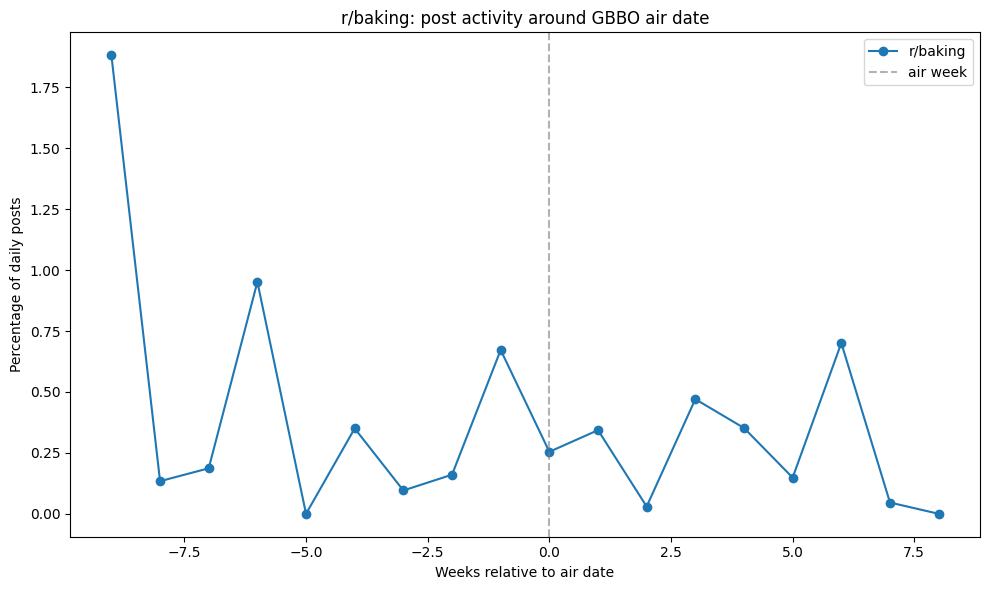

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(baking_weekly['week_bucket'], baking_weekly['share']*100, marker='o', label='r/baking')

ax.axvline(0, color='gray', linestyle='--', alpha=0.6, label='air week')

ax.set_xlabel('Weeks relative to air date')
ax.set_ylabel('Percentage of daily posts')
ax.set_title('r/baking: post activity around GBBO air date')
ax.legend()

plt.tight_layout()
plt.show()